# Parameter estimation demo - E. coli glycolysis

End-to-end walkthrough of `GlycolysisParameterEstimator`
(`src/param_estimation_parmest.py`): the two estimation workflows, the prediction /
RMSE diagnostics, and global-search multistart.

**Prerequisite (for the estimation cells):** an NLP solver for Pyomo. Install once:

```bash
conda install -n SaaLab -c conda-forge ipopt
```

Run this notebook with the SaaLab env so ipopt is on PATH:
`/Users/gabbi/miniconda3/envs/SaaLab/bin/python`.

Cells are tagged **[casadi-only]** (run without ipopt) or **[needs ipopt]**.


In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import param_estimation_parmest as P
from param_estimation_parmest import (
    GlycolysisParameterEstimator, REPORT_FIXED_PARAMS, check_solver,
)

# check_solver raises a clear message if ipopt is missing (skip estimation if so).
try:
    HAS_IPOPT = check_solver("ipopt")
except RuntimeError as exc:
    HAS_IPOPT = False
    print(exc)
print("ipopt available:", HAS_IPOPT)


ipopt available: True


## 1. Build the estimator

`fixed_params=REPORT_FIXED_PARAMS` holds the 13 report-fixed parameters and
estimates the remaining 24. Give `free_params=[...]` or `fixed_params=[...]`
(either one) to choose what is estimated.


In [2]:
est = GlycolysisParameterEstimator(
    conditions=["KO02", "KO03", "KO05"],   # subset for a fast demo; omit for all 22
    fixed_params=REPORT_FIXED_PARAMS,
)
print(est.summary())


GlycolysisParameterEstimator
  conditions       : 3
  free parameters  : 24 / 37
  fixed parameters : 13
  data points      : 42
  objective        : SSE_weighted
  imbalanced u_e   : free decision vars
  estimated        : False


## 2. Prediction and RMSE  **[casadi-only]**

`predict()` solves the steady state at the current parameters (CasADi, no ipopt)
and returns a `Prediction` with:
- `.predicted` / `.real` -- aligned (conditions x 18 outputs) DataFrames, plot-ready,
- `.rmse` -- dict `{met, flux, data_norm, weighted}`,
- `.per_output` -- raw RMSE per measured output (Series).

`weighted` is in sigma units (~1 means the fit sits at the measurement noise floor).


In [3]:
pred_lit = est.predict()                 # at literature parameters
print(pred_lit.summary())
pred_lit.per_output.sort_values(ascending=False).round(3)


Prediction over 3 condition(s), 18 outputs (42 measured cells):
  RMSE met       = 3.556 mM
  RMSE flux      = 1.049 mmol/gDCW/h
  RMSE data_norm = 118.2 (dimensionless, column-mean normalized)
  RMSE weighted  = 204.2 (sigma units; ~1 = at noise floor)
  worst-fit outputs: C_fbp=6.89, C_3pg=4.08, C_pep=3.46


C_fbp     6.893
C_3pg     4.080
C_pep     3.465
C_dhap    2.681
v_eno     1.996
v_pgk     1.915
v_gpmA    1.491
C_g6p     0.682
C_f6p     0.221
v_pgi     0.149
v_pts     0.107
v_gapA    0.030
v_pfkB    0.030
v_fbaA    0.000
v_tpiA    0.000
dtype: float64

## 3. Estimation 1: estimate -> covariance -> sensitivity  **[needs ipopt]**

The core workflow: fit the free parameters (weighted least squares), then quantify
their uncertainty (covariance / correlation) and local sensitivity (G matrices, FIM).
All matrix outputs are labeled DataFrames, ready to plot.


In [4]:
if HAS_IPOPT:
    theta = est.estimate()
    print("objective at theta_hat:", round(est.obj_value, 3))
    display(theta.round(4).to_frame("theta_hat").T)


objective at theta_hat: 111.917


,v_max_1,Ka1_1,K_g6p_1,Ks_g6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,kcat_f_3,Ks_fbp_4,kcat_f_4,...,Kp_nadh_6,kcat_f_7,Ks_pgp_7,Ks_adp_7,Ks_3pg_7,Ks_atp_7,kcat_f_8,Ks_3pg_8,kcat_f_9,Ks_2pg_9
theta_hat,84.3228,2.5753,33.46,25.6982,4291.0166,1.0925,1.0101,694.6642,5.9283,267.6091,...,25.5865,2567.387,0.5708,0.0331,25.7996,25.6869,1499.817,25.5215,1561.821,22.7425


In [5]:
if HAS_IPOPT:
    cov  = est.covariance()              # parameter covariance (DataFrame)
    corr = est.correlation_matrix()      # correlation r_ij (DataFrame)
    fim  = est.fisher_information_matrix()
    print("cov", cov.shape, "| corr", corr.shape, "| fim", fim.shape)


cov (24, 24) | corr (24, 24) | fim (24, 24)


In [6]:
if HAS_IPOPT:
    G = est.sensitivity_matrix()         # {condition: 18 x 37 DataFrame}
    print("sensitivity per condition:", {c: g.shape for c, g in G.items()})
    G["KO02"].head()


sensitivity per condition: {'KO02': (18, 37), 'KO03': (18, 37), 'KO05': (18, 37)}


In [7]:
if HAS_IPOPT:
    pred_fit = est.predict()             # prediction at the fitted parameters
    rmse_tbl = pd.DataFrame({"literature": pred_lit.rmse, "fitted": pred_fit.rmse})
    print(rmse_tbl.round(4))             # RMSE should drop after fitting


           literature   fitted
met            3.5561   0.6481
flux           1.0493   1.0493
data_norm    118.2356  11.9379
weighted     204.2151  13.8423


## 4. Plots: correlation, per-output RMSE, parity

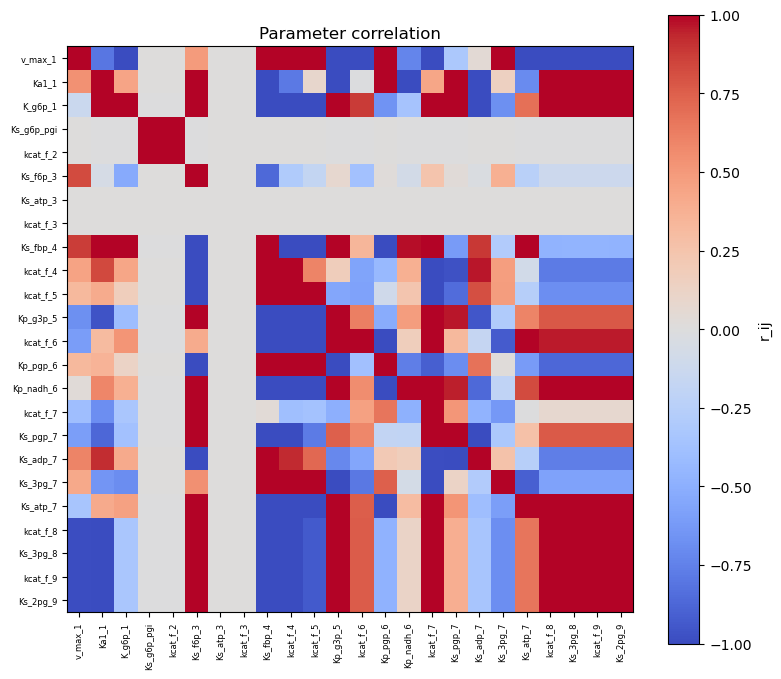

In [8]:
if HAS_IPOPT:
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
    ax.set_yticks(range(len(corr.index)));   ax.set_yticklabels(corr.index, fontsize=6)
    fig.colorbar(im, ax=ax, label="r_ij"); ax.set_title("Parameter correlation")
    plt.tight_layout(); plt.show()


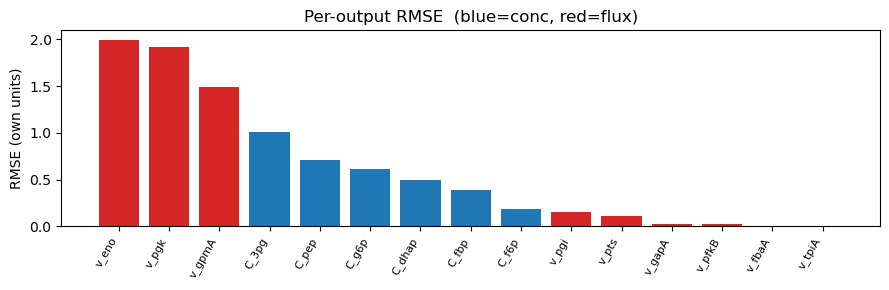

In [9]:
# per-output RMSE bar (casadi-only; uses the fitted prediction if available)
pred_show = pred_fit if HAS_IPOPT else pred_lit
po = pred_show.per_output.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3))
colors = ["tab:blue" if k.startswith("C_") else "tab:red" for k in po.index]
ax.bar(range(len(po)), po.to_numpy(), color=colors)
ax.set_xticks(range(len(po))); ax.set_xticklabels(po.index, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("RMSE (own units)"); ax.set_title("Per-output RMSE  (blue=conc, red=flux)")
plt.tight_layout(); plt.show()


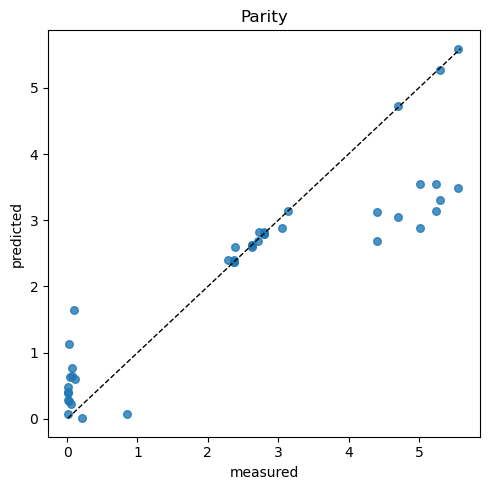

In [10]:
# parity plot: predicted vs measured over all measured cells
pv = pred_show.predicted.to_numpy().ravel()
rv = pred_show.real.to_numpy().ravel()
m = ~(np.isnan(pv) | np.isnan(rv))
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rv[m], pv[m], s=30, alpha=0.8)
lim = [min(rv[m].min(), pv[m].min()), max(rv[m].max(), pv[m].max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("measured"); ax.set_ylabel("predicted"); ax.set_title("Parity")
plt.tight_layout(); plt.show()


## 5. Estimation 2: global multistart  **[needs ipopt]**

A non-convex estimation can have several local optima, so a single fit may not be
global. `multistart` runs many starts and keeps the best, with two engines:

- **`engine="solver"`** -- `pyo.SolverFactory("multistart")`, the Pyomo *meta-solver*.
  It re-solves the SAME model (here parmest's extensive form) from many randomized
  initial points using an inner local solver (ipopt) and keeps the best feasible
  objective. Key options: `iterations` (number of restarts), `strategy`
  (`"rand"`, `"rand_distributed"`, `"midpoint_guess_and_bound"`,
  `"rand_guess_and_bound"`), `solver` (the inner NLP solver).
- **`engine="sampling"`** -- restarts the whole `theta_est()` from perturbed initial
  *parameter* values (wide, seeded). More robust when the EF path will not re-solve.
- **`engine="auto"`** (default) -- try `"solver"`, fall back to `"sampling"`.

The result reports global-search diagnostics: `all_runs` (sorted by objective, with
a `converged` flag), `n_converged`, `obj_median`, and `frac_within` (fraction of
converged starts within 1% of the best -- low means many basins, so add more starts).


In [11]:
if HAS_IPOPT:
    ms = est.multistart(method="multistart", engine="sampling", n_starts=8, seed=0)
    print("engine:", ms["engine"], "| best_obj:", round(ms["best_obj"], 3),
          "| n_converged:", ms["n_converged"],
          "| obj_median:", round(ms["obj_median"], 3),
          "| frac_within:", round(ms["frac_within"], 3))
    display(ms["all_runs"][["start", "obj_value", "converged"]])


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


engine: sampling | best_obj: 112.933 | n_converged: 2 | obj_median: 119.165 | frac_within: 0.5


,start,obj_value,converged
0,1,112.933231,True
1,3,125.396327,True
2,0,NaN,False
3,2,NaN,False
4,4,NaN,False
5,5,NaN,False
6,6,NaN,False
7,7,NaN,False


In [12]:
if HAS_IPOPT:
    ms_solver = est.multistart(method="multistart", engine="solver",
                               n_starts=6, seed=0, strategy="rand")
    print("engine:", ms_solver["engine"], "| best_obj:", round(ms_solver["best_obj"], 3))
    display(ms_solver["all_runs"][["start", "obj_value", "converged"]])


model.name="_Q_opt";
    - termination condition: maxIterations
    - message from solver: Ipopt 3.14.19\x3a Maximum Number of Iterations
      Exceeded.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


model.name="_Q_opt";
    - termination condition: infeasible
    - message from solver: Ipopt 3.14.19\x3a Converged to a locally infeasible
      point. Problem may be infeasible.


engine: solver | best_obj: 111.405


,start,obj_value,converged
0,single,111.404536,True
1,multistart,149782.971021,True


## 6. Bootstrap and profile likelihood  **[needs ipopt]**

- **Bootstrap** (`method="bootstrap"`) resamples whole conditions and re-fits, giving
  a distribution of theta. It needs more distinct conditions than free parameters, so
  the demo uses a small free set over more conditions.
- **Profile likelihood** scans a parameter and runs the chi2 likelihood-ratio test.


In [13]:
if HAS_IPOPT:
    est_small = GlycolysisParameterEstimator(
        conditions=P.available_conditions()[:8],
        free_params=["kcat_f_2", "kcat_f_3"],
    )
    boot = est_small.multistart(method="bootstrap", n_starts=5, seed=0)
    print("bootstrap all_runs:", boot["all_runs"].shape)
    display(boot["stats"].round(4))


bootstrap all_runs: (5, 2)


,mean,std,q05,q50,q95
kcat_f_2,49676.5871,282.6055,49360.3475,49678.2605,49966.0857
kcat_f_3,148.2723,42.0960,97.4501,159.6708,193.8780


In [14]:
if HAS_IPOPT:
    prof = est_small.profile_likelihood(free_params=["kcat_f_2"], n_grid=5,
                                        alphas=(0.95,))
    print("theta_hat:", float(prof["theta"]["kcat_f_2"]),
          "| obj:", round(prof["obj_value"], 3))
    display(prof["likelihood_ratio"])


theta_hat: 49300.03094304959 | obj: 51.533


,kcat_f_2,obj,0.95
0,24650.015472,51.525425,True
1,36975.023207,51.530028,True
2,49300.030943,51.532330,True
3,61625.038679,51.533719,True
4,73950.046415,51.534632,True
